## Завантаження

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

In [6]:
csv_table_file = './experiments/reward-habits-controlled-factored-experiment-table.csv'
df = pd.read_csv(csv_table_file, skiprows=6)

## Первинний аналіз

In [7]:
df.head()

,[run number],low-reward,high-reward,crowding-out-rate,habit-learning-rate,[step],high-reward-crowding-out-effect,low-reward-persistence-effect,"choice-rate ""control"" ""withdrawal""","choice-rate ""low-salience"" ""withdrawal""","choice-rate ""high-salience"" ""withdrawal""","mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience"""
0,2,0.2,0.7,0.01,0.005,0,0.0,0.0,0.0,0.0,0.0,0.509355,0.497622,0.505742,0.202979,0.191866,0.197857
1,2,0.2,0.7,0.01,0.005,1,0.0,0.0,0.0,0.0,0.0,0.509355,0.497622,0.505742,0.202423,0.191955,0.196719
2,6,0.2,0.7,0.01,0.005,0,0.0,0.0,0.0,0.0,0.0,0.499030,0.501087,0.489180,0.206322,0.202736,0.203594
3,5,0.2,0.7,0.01,0.005,0,0.0,0.0,0.0,0.0,0.0,0.505627,0.496245,0.503334,0.193418,0.199857,0.205000
4,9,0.2,0.7,0.01,0.005,0,0.0,0.0,0.0,0.0,0.0,0.488199,0.501307,0.505232,0.209344,0.199440,0.202214


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244620 entries, 0 to 244619
Data columns (total 17 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   [run number]                               244620 non-null  int64  
 1   low-reward                                 244620 non-null  float64
 2   high-reward                                244620 non-null  float64
 3   crowding-out-rate                          244620 non-null  float64
 4   habit-learning-rate                        244620 non-null  float64
 5   [step]                                     244620 non-null  int64  
 6   high-reward-crowding-out-effect            244620 non-null  float64
 7   low-reward-persistence-effect              244620 non-null  float64
 8   choice-rate "control" "withdrawal"         244620 non-null  float64
 9   choice-rate "low-salience" "withdrawal"    244620 non-null  float64
 10  choice-r

In [9]:
df.describe()

,[run number],low-reward,high-reward,crowding-out-rate,habit-learning-rate,[step],high-reward-crowding-out-effect,low-reward-persistence-effect,"choice-rate ""control"" ""withdrawal""","choice-rate ""low-salience"" ""withdrawal""","choice-rate ""high-salience"" ""withdrawal""","mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience"""
count,244620.000000,244620.00000,244620.000000,244620.00000,244620.000000,244620.000000,244620.000000,244620.000000,244620.000000,244620.000000,244620.000000,244620.000000,244620.000000,244620.000000,244620.000000,244620.000000,244620.000000
mean,810.500000,0.30000,0.866667,0.03000,0.025000,75.000000,-0.016985,0.021444,0.276158,0.297602,0.259173,0.500228,0.526601,0.399141,0.545252,0.607375,0.650233
std,467.654585,0.08165,0.124722,0.01633,0.018708,43.589079,0.051302,0.030139,0.346234,0.370573,0.325547,0.008051,0.021056,0.101807,0.314787,0.306848,0.290269
min,1.000000,0.20000,0.700000,0.01000,0.005000,0.000000,-0.249816,-0.055322,0.000000,0.000000,0.000000,0.475541,0.466417,0.153504,0.133440,0.159619,0.163216
25%,405.750000,0.20000,0.700000,0.01000,0.005000,37.000000,-0.008246,0.000000,0.000000,0.000000,0.000000,0.494713,0.507999,0.325911,0.180659,0.289535,0.382199
50%,810.500000,0.30000,0.900000,0.03000,0.020000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500293,0.529017,0.426294,0.602582,0.670793,0.732911
75%,1215.250000,0.40000,1.000000,0.05000,0.050000,113.000000,0.000000,0.044298,0.721985,0.783584,0.619763,0.505891,0.543369,0.485971,0.826736,0.896071,0.927927
max,1620.000000,0.40000,1.000000,0.05000,0.050000,150.000000,0.184694,0.212134,0.847305,0.894895,0.840841,0.526466,0.576264,0.530794,0.966125,0.988681,0.996772


## Розподіл результатів

<Axes: >

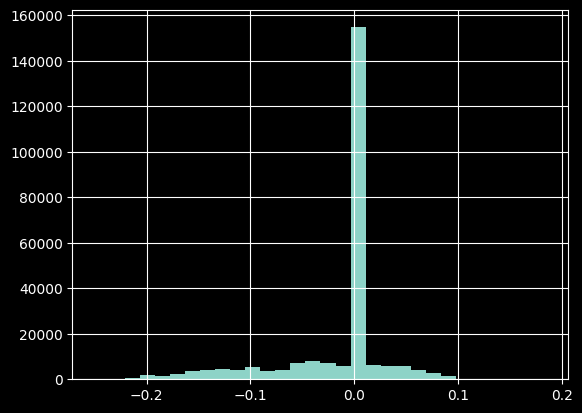

In [10]:
df["high-reward-crowding-out-effect"].hist(bins=30)

<Axes: >

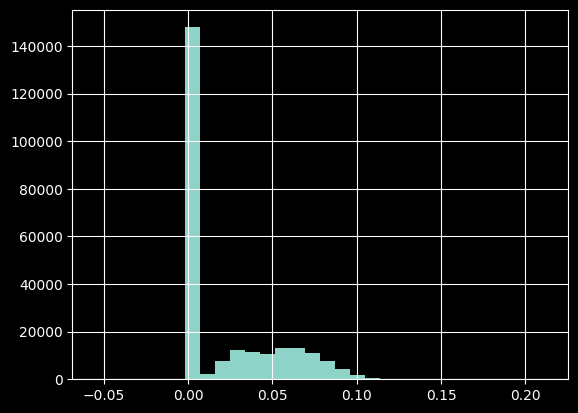

In [11]:
df["low-reward-persistence-effect"].hist(bins=30)

## Main Effects

In [12]:
df.groupby("crowding-out-rate")[
    "high-reward-crowding-out-effect"
].mean()

crowding-out-rate
0.01    0.008108
0.03   -0.018915
0.05   -0.040149
Name: high-reward-crowding-out-effect, dtype: float64

[]

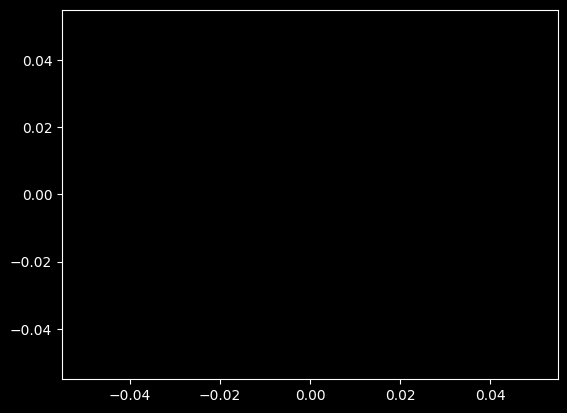

In [13]:
plt.plot(marker="o")

## Heatmaps

In [14]:
pivot = df.pivot_table(
    values="high-reward-crowding-out-effect",
    index="habit-learning-rate",
    columns="crowding-out-rate",
    aggfunc="mean"
)

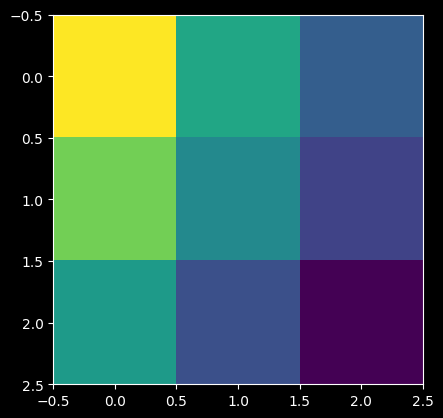

In [15]:
plt.imshow(pivot)

## Interaction plots

In [16]:
## Random Forest